In [ ]:
#importing weather data for Hof
import pandas as pd
import requests
# URL of the webpage containing JSON data
url = "http://139.174.11.24/data?dataset=weatherdataforcities&start=2019-01-01&end=2023-12-31&cityName=Hof"

# Fetch the data from the URL
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    # Parse JSON data
    hof_data = response.json()

    # Convert the data to a DataFrame
    hof_df = pd.DataFrame.from_dict(hof_data , orient='index')

    # Reset the index to convert the timestamp to a column
    hof_df.reset_index(inplace=True)

else:
    print("Failed to fetch data. Status code:", response.status_code)





In [ ]:

# drop unwanted columns

hof_df = hof_df.drop(columns = ["index", "time","snow","cityName"])

hof_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   temp    43824 non-null  float64
 1   dwpt    43824 non-null  float64
 2   rhum    43824 non-null  float64
 3   prcp    43824 non-null  float64
 4   wdir    43824 non-null  float64
 5   wspd    43824 non-null  float64
 6   wpgt    43824 non-null  float64
 7   pres    43824 non-null  float64
 8   tsun    43750 non-null  float64
 9   coco    43824 non-null  float64
dtypes: float64(10)
memory usage: 3.3 MB


In [ ]:
hof_df.head()

,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco
0,4.6,4.0,96.0,0.0,260.0,10.1,23.0,1031.4,0.0,4.0
1,4.5,3.9,96.0,0.0,250.0,8.3,21.0,1030.7,0.0,4.0
2,4.7,4.0,95.0,0.0,240.0,7.9,16.0,1030.0,0.0,7.0
3,4.6,3.6,93.0,0.0,250.0,9.0,21.0,1028.8,0.0,4.0
4,4.3,2.8,90.0,0.0,250.0,11.9,27.0,1027.8,0.0,4.0


In [ ]:
#Checking for null values
hof_df.isnull().sum()

temp     0
dwpt     0
rhum     0
prcp     0
wdir     0
wspd     0
wpgt     0
pres     0
tsun    74
coco     0
dtype: int64

In [ ]:
# find the percentage of missing values in each feature
hof_df.isnull().sum()/len(hof_df) *100

temp    0.000000
dwpt    0.000000
rhum    0.000000
prcp    0.000000
wdir    0.000000
wspd    0.000000
wpgt    0.000000
pres    0.000000
tsun    0.168857
coco    0.000000
dtype: float64

In [ ]:
#Using Linear Regression Imputation to fill missing values in the tsun feature
from sklearn.linear_model import LinearRegression

# seperate the null  values of the tsun feature
test =  hof_df[hof_df["tsun"].isnull()]
X_test = test.drop(columns = ["tsun"] )

#Dropping the null values from the dataset
train = hof_df.dropna()
#Splitting the train data into target and feature
X_train= train.drop(columns = ["tsun"])
y_train = train["tsun"]

#Calling the linear regression model
lr = LinearRegression()
#Fitting the tranining data in to the model
lr.fit(X_train, y_train)
#Predicting the missing tsun values
y_pred = lr.predict(X_test)

#Replacing the missing values with the model prediction
hof_df.loc[hof_df.tsun.isnull(),"tsun"] = y_pred






In [ ]:
#Check if missing values still exists for the tsun feature
hof_df.isnull().sum()/len(hof_df) *100

temp    0.0
dwpt    0.0
rhum    0.0
prcp    0.0
wdir    0.0
wspd    0.0
wpgt    0.0
pres    0.0
tsun    0.0
coco    0.0
dtype: float64

In [ ]:
# Check if -99999 exists in all columns and print columns where it exists
columns_with_value = hof_df.apply(lambda col: col.name if -99999 in col.values else None).dropna()

if len(columns_with_value) > 0:
    print(f"The value '{-99999}' exists in the following columns:")
    for col in columns_with_value:
        print(col)
else:
    print(f"The value '{-99999}' does not exist in any column.")

The value '-99999' does not exist in any column.


In [ ]:
hof_df.describe()

,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco
count,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000
mean,8.843624,4.317787,76.498768,0.078078,198.776606,10.773738,22.017431,1016.960262,11.722923,4.739093
std,8.026171,6.244665,18.380301,0.483102,90.389665,5.816435,11.664793,9.317009,21.209232,3.485454
min,-18.200000,-19.600000,14.000000,0.000000,0.000000,0.000000,2.000000,980.100000,-12.336077,0.000000
25%,2.400000,-0.300000,65.000000,0.000000,140.000000,6.500000,13.000000,1011.400000,0.000000,3.000000
50%,8.200000,4.400000,82.000000,0.000000,210.000000,9.700000,20.400000,1017.100000,0.000000,4.000000
75%,14.700000,9.300000,91.000000,0.000000,260.000000,14.000000,29.000000,1022.800000,12.000000,7.000000
max,34.600000,21.100000,100.000000,31.500000,360.000000,49.700000,114.000000,1048.300000,60.000000,25.000000


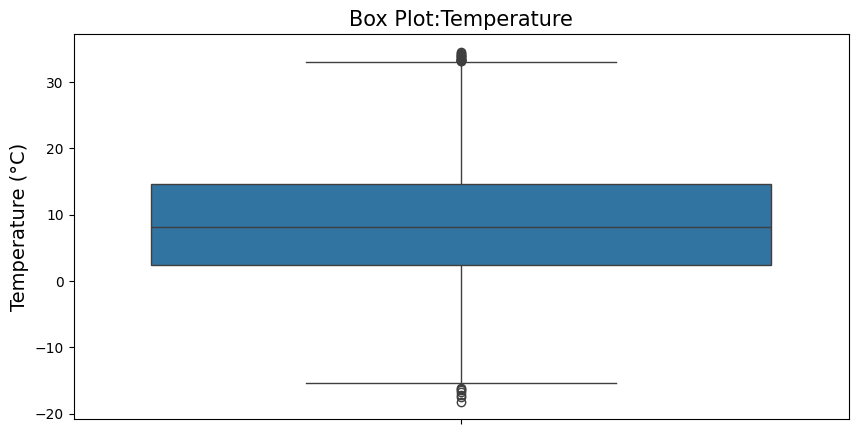

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
fig = plt.figure(figsize=(10,5))
sns.boxplot(hof_df.temp)
plt.title('Box Plot:Temperature', fontsize=15)
plt.ylabel('Temperature (°C)', fontsize=14)
plt.show()

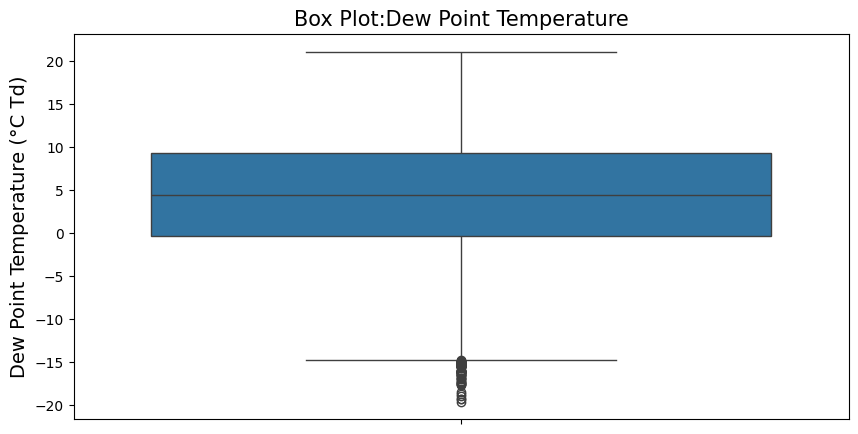

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(hof_df.dwpt)
plt.title('Box Plot:Dew Point Temperature', fontsize=15)
plt.ylabel('Dew Point Temperature (°C Td)', fontsize=14)
plt.show()

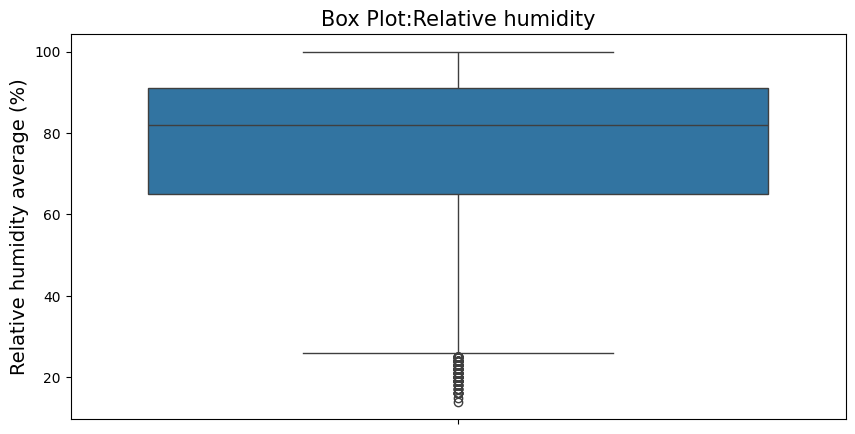

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(hof_df.rhum)
plt.title('Box Plot:Relative humidity', fontsize=15)
plt.ylabel('Relative humidity average (%)', fontsize=14)
plt.show()

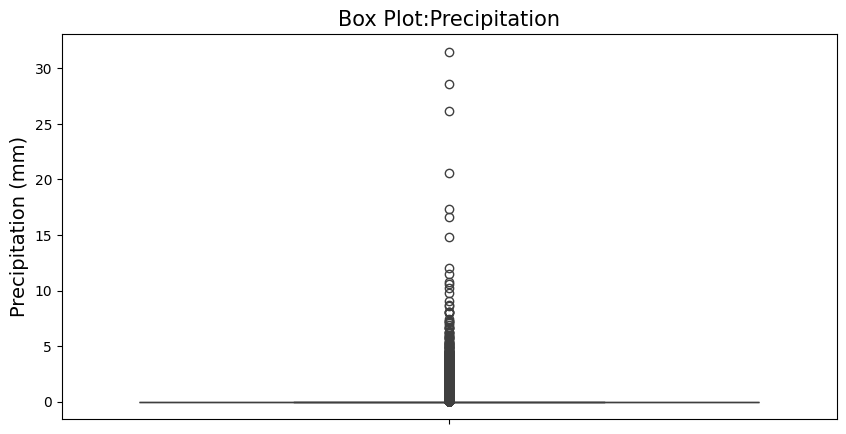

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(hof_df.prcp)
plt.title('Box Plot:Precipitation', fontsize=15)
plt.ylabel('Precipitation (mm)', fontsize=14)
plt.show()

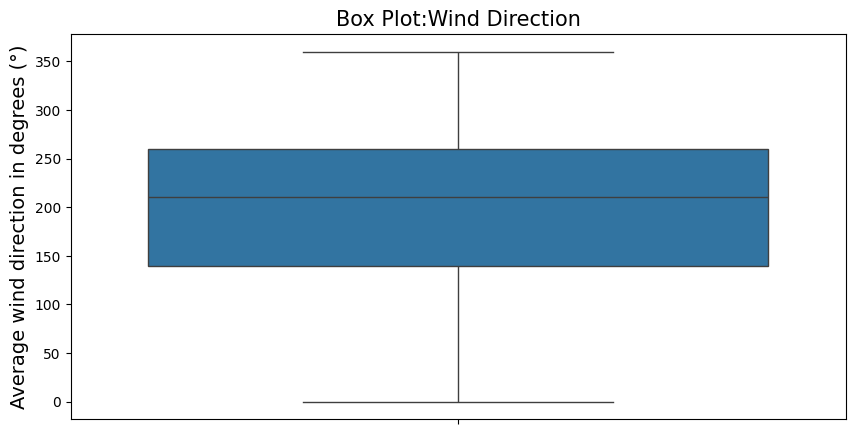

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(hof_df.wdir)
plt.title('Box Plot:Wind Direction', fontsize=15)
plt.ylabel('Average wind direction in degrees (°)', fontsize=14)
plt.show()

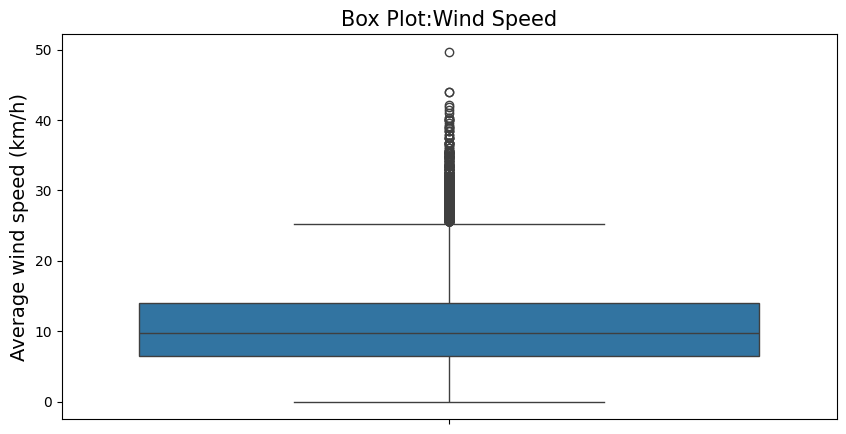

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(hof_df.wspd)
plt.title('Box Plot:Wind Speed', fontsize=15)
plt.ylabel('Average wind speed (km/h)', fontsize=14)
plt.show()

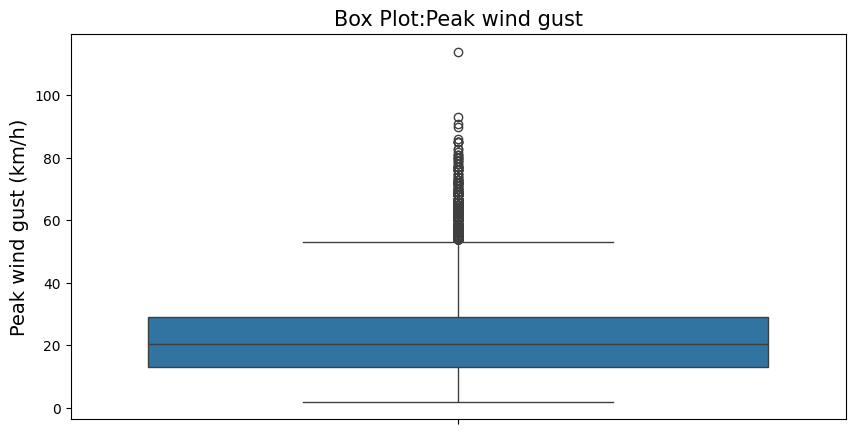

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(hof_df.wpgt)
plt.title('Box Plot:Peak wind gust', fontsize=15)
plt.ylabel('Peak wind gust (km/h)', fontsize=14)
plt.show()

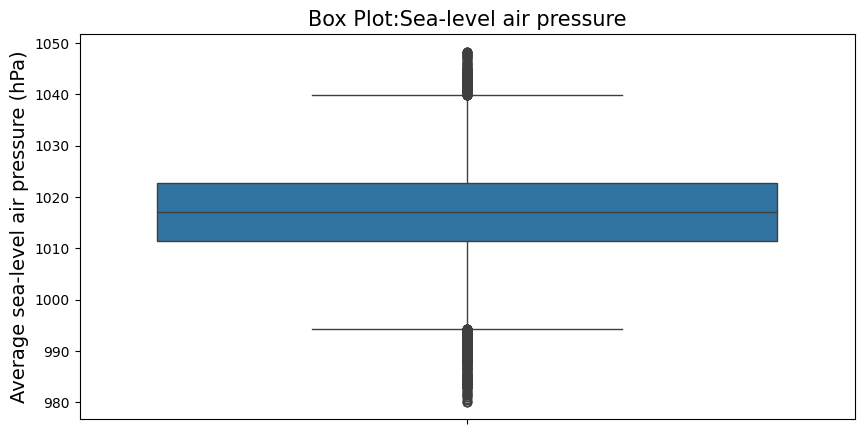

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(hof_df.pres)
plt.title('Box Plot:Sea-level air pressure', fontsize=15)
plt.ylabel('Average sea-level air pressure (hPa)', fontsize=14)
plt.show()

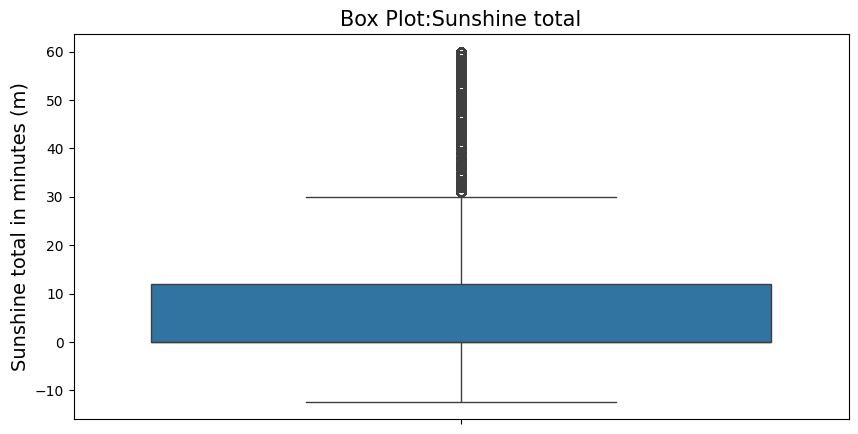

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(hof_df.tsun)
plt.title('Box Plot:Sunshine total', fontsize=15)
plt.ylabel('Sunshine total in minutes (m)', fontsize=14)
plt.show()

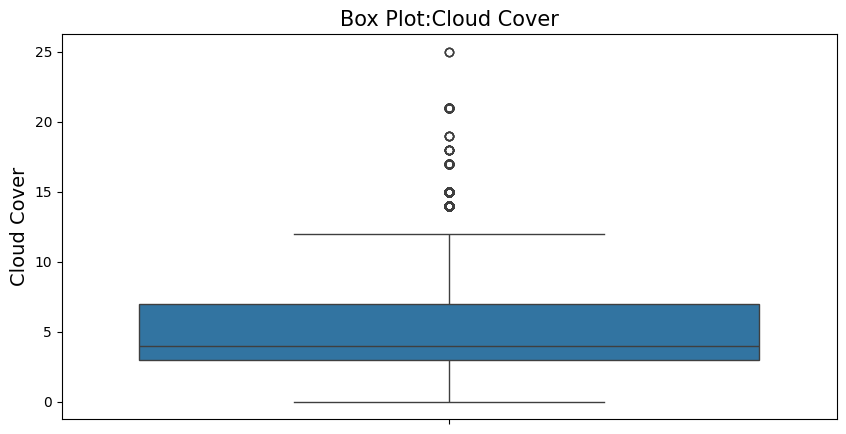

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(hof_df.coco)
plt.title('Box Plot:Cloud Cover', fontsize=15)
plt.ylabel('Cloud Cover', fontsize=14)
plt.show()

APPLYING LOF ON WEATHER DATASET

In [ ]:
import numpy as np
import pandas as pd
from sklearn.neighbors import LocalOutlierFactor


# Number of neighbors for LOF
n_neighbors = 20

# Dictionary to store the percentage of outliers for each feature
outlier_percentages = {}

# Apply LOF to each feature
for feature in hof_df.columns:
# Reshape the data for LOF
 X = hof_df[[feature]].values

 # Fit the LOF model
 lof = LocalOutlierFactor(n_neighbors=n_neighbors)
 y_pred = lof.fit_predict(X)

 # Identify the outliers
 outliers = y_pred == -1

 # Calculate the percentage of outliers
 percentage_outliers = np.mean(outliers) * 100
 outlier_percentages[feature] = percentage_outliers

 print(f'Percentage of outliers in Hof weather {feature}: {percentage_outliers:.2f}%')

Percentage of outliers in Hof weather temp: 0.38%
Percentage of outliers in Hof weather dwpt: 0.11%
Percentage of outliers in Hof weather rhum: 0.05%
Percentage of outliers in Hof weather prcp: 0.07%
Percentage of outliers in Hof weather wdir: 0.51%
Percentage of outliers in Hof weather wspd: 0.10%
Percentage of outliers in Hof weather wpgt: 0.19%
Percentage of outliers in Hof weather pres: 0.45%
Percentage of outliers in Hof weather tsun: 0.12%
Percentage of outliers in Hof weather coco: 0.05%


NAIVE BAYES ON WEATHER DATASET

In [ ]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from scipy.stats import norm


# Extract features
X = hof_df.values

# Fit Gaussian Naive Bayes model
gnb = GaussianNB()
gnb.fit(X, np.zeros(X.shape[0]))  # Dummy target variable

# Calculate likelihoods for each data point
means = gnb.theta_
variances = gnb.var_
likelihoods = np.zeros(X.shape[0])

# Ensure means and variances are in correct shape
if means.ndim == 1:
    means = means.reshape(1, -1)
if variances.ndim == 1:
    variances = variances.reshape(1, -1)

# Calculate likelihoods for each data point
for i, x in enumerate(X):
    likelihood = 1
    for j in range(X.shape[1]):
        likelihood *= norm.pdf(x[j], loc=means[0][j], scale=np.sqrt(variances[0][j]))
    likelihoods[i] = likelihood

# Determine anomalies
threshold = np.percentile(likelihoods, 10)  # for example, consider the bottom 10% as anomalies
anomalies = np.where(likelihoods < threshold)[0]

# Calculate percentage of anomalies for each feature
anomalies_hof_df= hof_df.iloc[anomalies]
total_anomalies = len(anomalies)
total_data_points = len(hof_df)

# Calculate anomaly percentage for each feature
feature_anomalies_percentage = {}
for feature in hof_df.columns:
    feature_anomalies_count = (anomalies_hof_df[feature] != hof_df[feature].mode().iloc[0]).sum()
    feature_anomalies_percentage[feature] = (feature_anomalies_count / total_data_points) * 100

print("Number of anomalies detected:", total_anomalies)
print("Percentage of anomalies for each feature:")
for feature, percentage in feature_anomalies_percentage.items():
    print(f"{feature}: {percentage:.2f}%")


Number of anomalies detected: 4383
Percentage of anomalies for each feature:
temp: 9.91%
dwpt: 9.95%
rhum: 9.61%
prcp: 3.03%
wdir: 9.22%
wspd: 9.84%
wpgt: 9.72%
pres: 9.96%
tsun: 4.34%
coco: 9.13%


In [ ]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from scipy.stats import norm



# Initialize a dictionary to store anomaly information for each feature
anomaly_info = {}

# Loop through each feature
for feature in hof_df.columns:
    # Extract the feature values
    X = hof_df[[feature]].values

    # Fit Gaussian Naive Bayes model
    gnb = GaussianNB()
    gnb.fit(X, np.zeros(X.shape[0]))  # Dummy target variable

    # Calculate likelihoods for each data point
    means = gnb.theta_
    variances = gnb.var_
    likelihoods = np.zeros(X.shape[0])

    # Ensure means and variances are in correct shape
    if means.ndim == 1:
        means = means.reshape(1, -1)
    if variances.ndim == 1:
        variances = variances.reshape(1, -1)

    # Calculate likelihoods for each data point
    for i, x in enumerate(X):
        likelihood = norm.pdf(x[0], loc=means[0][0], scale=np.sqrt(variances[0][0]))
        likelihoods[i] = likelihood

    # Determine anomalies using mean and standard deviation
    mean_likelihood = np.mean(likelihoods)
    std_likelihood = np.std(likelihoods)
    threshold = mean_likelihood - 2 * std_likelihood  # 2 standard deviations below the mean
    anomalies = np.where(likelihoods < threshold)[0]

    # Calculate percentage of anomalies for this feature
    total_anomalies = len(anomalies)
    total_data_points = len(hof_df)
    anomaly_percentage = (total_anomalies / total_data_points) * 100

    # Store the anomaly information
    anomaly_info[feature] = {
        'total_anomalies': total_anomalies,
        'anomaly_percentage': anomaly_percentage,
        'anomalies': anomalies
    }

# Print results
for feature, info in anomaly_info.items():
    print(f"Feature: {feature}")
    print(f"  Number of anomalies detected: {info['total_anomalies']}")
    print(f"  Percentage of anomalies: {info['anomaly_percentage']:.2f}%")



Feature: temp
  Number of anomalies detected: 1911
  Percentage of anomalies: 4.36%
Feature: dwpt
  Number of anomalies detected: 1617
  Percentage of anomalies: 3.69%
Feature: rhum
  Number of anomalies detected: 2940
  Percentage of anomalies: 6.71%
Feature: prcp
  Number of anomalies detected: 1686
  Percentage of anomalies: 3.85%
Feature: wdir
  Number of anomalies detected: 1003
  Percentage of anomalies: 2.29%
Feature: wspd
  Number of anomalies detected: 2307
  Percentage of anomalies: 5.26%
Feature: wpgt
  Number of anomalies detected: 2266
  Percentage of anomalies: 5.17%
Feature: pres
  Number of anomalies detected: 2919
  Percentage of anomalies: 6.66%
Feature: tsun
  Number of anomalies detected: 5633
  Percentage of anomalies: 12.85%
Feature: coco
  Number of anomalies detected: 2775
  Percentage of anomalies: 6.33%


AUTOENCODER ON WEATHER DATASET

In [ ]:
# import numpy as np
# import pandas as pd
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, Dense
# from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import MinMaxScaler
# from keras.models import Sequential



# #to save all features
# features_auto_w = hof_df.columns.tolist()


# # DataFrame to store anomaly scores for each feature
# anomaly_scores_auto_w = pd.DataFrame(index=hof_df.index)

# # Loop through each feature
# for feature in features_auto_w :
#     # Scale the feature data
#     scaler = MinMaxScaler()
#     scaled_feature_auto_w  = scaler.fit_transform(hof_df[[feature]])

#     # Define the autoencoder model
#     model_auto_w  = Sequential([
#         Dense(32, activation='relu', input_shape=(1,)),
#         Dense(16, activation='relu'),
#         Dense(32, activation='relu'),
#         Dense(1, activation='sigmoid')
#     ])

#     model_auto_w .compile(optimizer='adam', loss='mean_squared_error')

#      #Train the autoencoder
#     model_auto_w.fit(scaled_feature_auto_w , scaled_feature_auto_w , epochs=50, batch_size=32, validation_split=0.1, verbose=0)

#     # Get reconstruction loss
#     reconstructed_feature_auto_w  = model_auto_w.predict(scaled_feature_auto_w )
#     reconstruction_loss_auto_w  = np.mean(np.square(scaled_feature_auto_w  - reconstructed_feature_auto_w ), axis=1)

#     # Store the reconstruction loss (anomaly score) in the DataFrame
#     anomaly_scores_auto_w [feature] = reconstruction_loss_auto_w



1370/1370 [==============================] - 2s 1ms/step


In [ ]:

# print(reconstruction_loss_auto_w)
# # Calculate the threshold as the 90th percentile of the reconstruction loss
# threshold_auto_w = np.percentile(reconstruction_loss_auto_w, 90)

#     # Identify anomalies
# anomalies_auto_w = reconstruction_loss_auto_w > threshold_auto_w

# for feature in features_auto_w:
#     anomalies_auto_w = anomaly_scores_auto_w[feature] > threshold_auto_w
#     anomaly_percentage_auto_w = np.mean(anomalies_auto_w) * 100
#     print(f'Feature: {feature}, Anomaly Percentage: {anomaly_percentage_auto_w:.2f}%')


#     # Store the reconstruction loss (anomaly score) in the DataFrame
# anomaly_scores_auto_w[feature] = reconstruction_loss_auto_w


# # Combine anomaly scores with original data for easier analysis
# combined_data_auto_w = pd.concat([hof_df, anomaly_scores_auto_w.add_suffix('_anomaly_score')], axis=1)

# # Save the combined data with anomaly scores
# combined_data_auto_w.to_csv('hof_df_with_anomaly_scores_auto_w.csv', index=False)

# # Display the first few rows of the combined data
# combined_data_auto_w.head()

[4.14978449e-08 4.14978449e-08 1.75410722e-08 ... 4.14978449e-08
 4.14978449e-08 4.14978449e-08]
Feature: temp, Anomaly Percentage: 93.29%
Feature: dwpt, Anomaly Percentage: 91.52%
Feature: rhum, Anomaly Percentage: 100.00%
Feature: prcp, Anomaly Percentage: 99.48%
Feature: wdir, Anomaly Percentage: 97.41%
Feature: wspd, Anomaly Percentage: 79.73%
Feature: wpgt, Anomaly Percentage: 85.34%
Feature: pres, Anomaly Percentage: 88.58%
Feature: tsun, Anomaly Percentage: 98.66%
Feature: coco, Anomaly Percentage: 4.86%


,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco,temp_anomaly_score,dwpt_anomaly_score,rhum_anomaly_score,prcp_anomaly_score,wdir_anomaly_score,wspd_anomaly_score,wpgt_anomaly_score,pres_anomaly_score,tsun_anomaly_score,coco_anomaly_score
0,4.6,4.0,96.0,0.0,260.0,10.1,23.0,1031.4,0.0,4.0,0.000002,0.000002,0.000008,6.544674e-08,1.568276e-05,8.067200e-07,1.908183e-07,2.863049e-06,1.386924e-07,4.149784e-08
1,4.5,3.9,96.0,0.0,250.0,8.3,21.0,1030.7,0.0,4.0,0.000002,0.000002,0.000008,6.544674e-08,4.318694e-07,4.270815e-08,1.116178e-07,3.199815e-06,1.386924e-07,4.149784e-08
2,4.7,4.0,95.0,0.0,240.0,7.9,16.0,1030.0,0.0,7.0,0.000002,0.000002,0.000025,6.544674e-08,2.256354e-06,6.670587e-07,3.033058e-07,2.605355e-06,1.386924e-07,1.754107e-08
3,4.6,3.6,93.0,0.0,250.0,9.0,21.0,1028.8,0.0,4.0,0.000002,0.000002,0.000010,6.544674e-08,4.318694e-07,3.963018e-08,1.116178e-07,4.865450e-07,1.386924e-07,4.149784e-08
4,4.3,2.8,90.0,0.0,250.0,11.9,27.0,1027.8,0.0,4.0,0.000002,0.000002,0.000012,6.544674e-08,4.318694e-07,1.403570e-06,1.228134e-06,4.118746e-07,1.386924e-07,4.149784e-08


APPLYING XGBOOST ON WEATHER DATASET

In [ ]:

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Sample Data (Replace with your dataset)
# Assuming a dataframe with 100 rows and 10 features


# Define anomaly detection function
def detect_anomalies(Mun_df):
    anomalies = pd.DataFrame(index=Mun_df.index)
    anomaly_percentages = {}

    for feature in Mun_df.columns:
        X = Mun_df.drop(columns=[feature])
        y = Mun_df[feature]

        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Train XGBoost model
        model = XGBRegressor()
        model.fit(X_train, y_train)

        # Predict on the whole dataset
        y_pred = model.predict(X)

        # Calculate prediction errors
        errors = np.abs(y - y_pred)

        # Determine dynamic threshold using standard deviation
        mean_error = np.mean(errors)
        std_error = np.std(errors)
        threshold = mean_error + 2 * std_error  # Consider 2 standard deviations from the mean

        # Flag anomalies
        anomaly_flags = errors > threshold
        anomalies[feature] = anomaly_flags

        # Calculate anomaly percentage
        anomaly_percentages[feature] = (anomaly_flags.sum() / len(Mun_df)) * 100

        # Print summary
        print(f"Feature: {feature}")
        print(f"Threshold: {threshold:.4f}")
        print(f"Anomalies detected: {anomaly_flags.sum()}/{len(Mun_df)} ({anomaly_percentages[feature]:.2f}%)")
        print("-" * 40)

    return anomalies, anomaly_percentages

# Detect anomalies
anomalies_df, anomaly_percentages = detect_anomalies(hof_df)


# Print anomaly percentages
print("\nAnomaly Percentages per Feature:")
for feature, percentage in anomaly_percentages.items():
    print(f"{feature}: {percentage:.2f}%")


Feature: temp
Threshold: 0.2942
Anomalies detected: 1595/43824 (3.64%)
----------------------------------------
Feature: dwpt
Threshold: 0.3024
Anomalies detected: 1507/43824 (3.44%)
----------------------------------------
Feature: rhum
Threshold: 2.2064
Anomalies detected: 2003/43824 (4.57%)
----------------------------------------
Feature: prcp
Threshold: 0.5592
Anomalies detected: 864/43824 (1.97%)
----------------------------------------
Feature: wdir
Threshold: 151.0395
Anomalies detected: 2506/43824 (5.72%)
----------------------------------------
Feature: wspd
Threshold: 2.7173
Anomalies detected: 1813/43824 (4.14%)
----------------------------------------
Feature: wpgt
Threshold: 5.2914
Anomalies detected: 1676/43824 (3.82%)
----------------------------------------
Feature: pres
Threshold: 13.1043
Anomalies detected: 2115/43824 (4.83%)
----------------------------------------
Feature: tsun
Threshold: 25.0347
Anomalies detected: 2656/43824 (6.06%)
------------------------------

IRRADIATION DATASET


In [1]:
import pandas as pd
import requests
#importing irradiation data for Meiningen
# URL of the webpage containing JSON data
url = "http://139.174.11.24/data?dataset=irradiationdataforcities&start=2019-01-01&end=2023-12-31&cityName=Hof"

# Fetch the data from the URL
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    # Parse JSON data
    data = response.json()

    # Convert the data to a DataFrame
    df_irrad = pd.DataFrame.from_dict(data, orient='index')


else:
    print("Failed to fetch data. Status code:", response.status_code)


In [2]:
df_irrad.head(2)

,time,Observation period,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI,Reliability,cityName
1546300800000,2019-01-01 00:00:00,2019-01-01T00:00:00.0/2019-01-01T00:15:00.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,1.0000,Hof
1546301700000,2019-01-01 00:15:00,2019-01-01T00:15:00.0/2019-01-01T00:30:00.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,1.0000,Hof


In [3]:

# drop unwanted columns
clean_df = df_irrad.drop(columns = ["time", "Observation period", "Reliability", "cityName"])
df_irrad.info()

<class 'pandas.core.frame.DataFrame'>
Index: 175296 entries, 1546300800000 to 1704066300000
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   time                175296 non-null  object 
 1   Observation period  175296 non-null  object 
 2   TOA                 175296 non-null  object 
 3   Clear sky GHI       175296 non-null  object 
 4   Clear sky BHI       175296 non-null  object 
 5   Clear sky DHI       175296 non-null  object 
 6   Clear sky BNI       175296 non-null  object 
 7   GHI                 175296 non-null  float64
 8   BHI                 175296 non-null  object 
 9   DHI                 175296 non-null  object 
 10  BNI                 175296 non-null  object 
 11  Reliability         175296 non-null  object 
 12  cityName            175296 non-null  object 
dtypes: float64(1), object(12)
memory usage: 18.7+ MB


In [5]:
df_HOF = clean_df.select_dtypes("object").astype("float")
df_HOF["GHI"] = clean_df["GHI"]

In [6]:
df_HOF.describe()

,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,BHI,DHI,BNI,GHI
count,175296.000000,175296.000000,175296.000000,175296.000000,175296.000000,175296.000000,175296.000000,175296.000000,175296.000000
mean,70.711309,51.130501,40.107925,11.022576,81.478264,17.410047,16.514584,34.782260,33.924630
std,91.544444,69.887422,57.530472,13.984570,92.159961,39.186219,25.151192,64.617829,54.420976
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.509200,0.642150,0.049150,0.570150,0.822950,0.000000,0.484000,0.000000,0.526200
75%,133.057400,93.431125,70.506100,20.680750,181.944400,8.258425,25.112050,36.263925,48.053025
max,293.919000,240.550100,218.970900,91.404300,257.864000,218.674500,128.406300,257.864000,239.835900


In [ ]:
#Get the percentage of null values in the dataset
clean_df.isnull().sum() /len(df_irrad) *(100)

TOA              0.0
Clear sky GHI    0.0
Clear sky BHI    0.0
Clear sky DHI    0.0
Clear sky BNI    0.0
GHI              0.0
BHI              0.0
DHI              0.0
BNI              0.0
dtype: float64

In [ ]:
clean_df.head(2)

,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI
1546300800000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546301700000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000


In [ ]:

# Check if -99999 exists in all columns and print columns where it exists
columns_with_value = clean_df.apply(lambda col: col.name if -99999 in col.values else None).dropna()

if len(columns_with_value) > 0:
    print(f"The value '{-99999}' exists in the following columns:")
    for col in columns_with_value:
        print(col)
else:
    print(f"The value '{-99999}' does not exist in any column.")

The value '-99999' does not exist in any column.


In [ ]:
clean_df

,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI
1546300800000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546301700000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546302600000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546303500000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546304400000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...
1704062700000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1704063600000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1704064500000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1704065400000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000


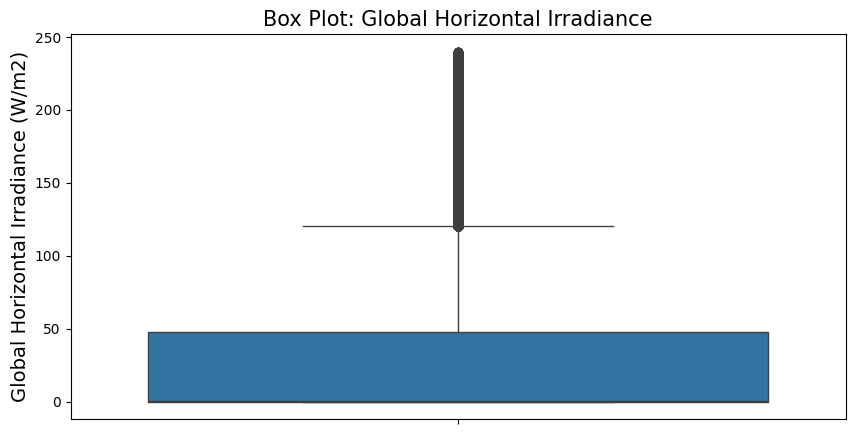

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(clean_df.GHI)
plt.title('Box Plot: Global Horizontal Irradiance', fontsize=15)
plt.ylabel('Global Horizontal Irradiance (W/m2)', fontsize=14)
plt.show()

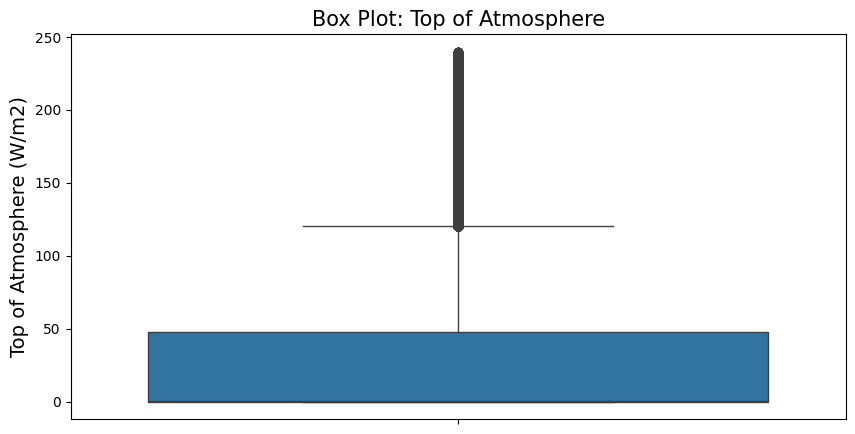

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(clean_df.GHI)
plt.title('Box Plot: Top of Atmosphere', fontsize=15)
plt.ylabel('Top of Atmosphere (W/m2)', fontsize=14)
plt.show()

LOF ON IRRADIATION DATASET

In [ ]:
import numpy as np
import pandas as pd
from sklearn.neighbors import LocalOutlierFactor

# Number of neighbors for LOF
n_neighbors = 20

# Dictionary to store the percentage of outliers for each feature
outlier_percentages = {}

# Apply LOF to each feature
for feature in clean_df.columns:
# Reshape the data for LOF
 X = clean_df[[feature]].values

 # Fit the LOF model
 lof = LocalOutlierFactor(n_neighbors=n_neighbors)
 y_pred = lof.fit_predict(X)

 # Identify the outliers
 outliers = y_pred == -1

 # Calculate the percentage of outliers
 percentage_outliers = np.mean(outliers) * 100
 outlier_percentages[feature] = percentage_outliers

 print(f'Percentage of outliers in HOF irradiation in {feature}: {percentage_outliers:.2f}%')

Percentage of outliers in HOF irradiation in TOA: 0.04%
Percentage of outliers in HOF irradiation in Clear sky GHI: 0.01%
Percentage of outliers in HOF irradiation in Clear sky BHI: 0.06%
Percentage of outliers in HOF irradiation in Clear sky DHI: 0.01%
Percentage of outliers in HOF irradiation in Clear sky BNI: 0.01%
Percentage of outliers in HOF irradiation in GHI: 0.01%
Percentage of outliers in HOF irradiation in BHI: 0.13%
Percentage of outliers in HOF irradiation in DHI: 0.01%
Percentage of outliers in HOF irradiation in BNI: 0.07%


NAIVE BAYES ON IRRADIATION DATASET

In [ ]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from scipy.stats import norm

# Assuming clean_Osna_Irrad is your DataFrame loaded from your dataset
# Example steps to handle data types and missing values

# Step 1: Check and Convert Data Types
# Convert all columns to numeric (float64)
clean_df =  clean_df.apply(pd.to_numeric, errors='coerce')

# Step 2: Handle Missing Values
clean_df =  clean_df.dropna()  # Drop rows with NaN values

# Extract features
X =  clean_df.values

# Fit Gaussian Naive Bayes model
gnb = GaussianNB()
gnb.fit(X, np.zeros(X.shape[0]))  # Dummy target variable

# Calculate likelihoods for each data point
means = gnb.theta_
variances = np.var(X, axis=0) + 1e-9  # Adding a small value for numerical stability

likelihoods = np.zeros(X.shape[0])

# Ensure means and variances are in correct shape
if means.ndim == 1:
    means = means.reshape(1, -1)
if variances.ndim == 1:
    variances = variances.reshape(1, -1)

# Calculate likelihoods for each data point
for i, x in enumerate(X):
    likelihood = 1
    for j in range(X.shape[1]):
        likelihood *= norm.pdf(x[j], loc=means[0][j], scale=np.sqrt(variances[0][j]))
    likelihoods[i] = likelihood

# Determine anomalies
threshold = np.percentile(likelihoods, 10)  # for example, consider the bottom 10% as anomalies
anomalies = np.where(likelihoods < threshold)[0]

# Calculate percentage of anomalies for each feature
anomalies_clean_df =  clean_df.iloc[anomalies]
total_anomalies = len(anomalies)
total_data_points = len(clean_df)

# Calculate anomaly percentage for each feature
feature_anomalies_percentage = {}
for feature in  clean_df.columns:
    feature_anomalies_count = (anomalies_clean_df[feature] !=  clean_df[feature].mode().iloc[0]).sum()
    feature_anomalies_percentage[feature] = (feature_anomalies_count / total_data_points) * 100

print("Number of anomalies detected:", total_anomalies)
print("Percentage of anomalies for each feature:")
for feature, percentage in feature_anomalies_percentage.items():
    print(f"{feature}: {percentage:.2f}%")


Number of anomalies detected: 17530
Percentage of anomalies for each feature:
TOA: 10.00%
Clear sky GHI: 10.00%
Clear sky BHI: 10.00%
Clear sky DHI: 10.00%
Clear sky BNI: 10.00%
GHI: 10.00%
BHI: 9.99%
DHI: 10.00%
BNI: 9.99%


In [ ]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from scipy.stats import norm


# Initialize a dictionary to store anomaly information for each feature
anomaly_info = {}

# Loop through each feature
for feature in clean_df.columns:
    # Extract the feature values
    X = clean_df[[feature]].values

    # Fit Gaussian Naive Bayes model
    gnb = GaussianNB()
    gnb.fit(X, np.zeros(X.shape[0]))  # Dummy target variable

    # Calculate likelihoods for each data point
    means = gnb.theta_
    variances = gnb.var_
    likelihoods = np.zeros(X.shape[0])

    # Ensure means and variances are in correct shape
    if means.ndim == 1:
        means = means.reshape(1, -1)
    if variances.ndim == 1:
        variances = variances.reshape(1, -1)

    # Calculate likelihoods for each data point
    for i, x in enumerate(X):
        likelihood = norm.pdf(x[0], loc=means[0][0], scale=np.sqrt(variances[0][0]))
        likelihoods[i] = likelihood

    # Determine anomalies using mean and standard deviation
    mean_likelihood = np.mean(likelihoods)
    std_likelihood = np.std(likelihoods)
    threshold = mean_likelihood - 2 * std_likelihood  # 2 standard deviations below the mean
    anomalies = np.where(likelihoods < threshold)[0]

    # Calculate percentage of anomalies for this feature
    total_anomalies = len(anomalies)
    total_data_points = len(clean_df)
    anomaly_percentage = (total_anomalies / total_data_points) * 100

    # Store the anomaly information
    anomaly_info[feature] = {
        'total_anomalies': total_anomalies,
        'anomaly_percentage': anomaly_percentage,
        'anomalies': anomalies
    }

# Print results
for feature, info in anomaly_info.items():
    print(f"Feature: {feature}")
    print(f"  Number of anomalies detected: {info['total_anomalies']}")
    print(f"  Percentage of anomalies: {info['anomaly_percentage']:.2f}%")



Feature: TOA
  Number of anomalies detected: 16157
  Percentage of anomalies: 9.22%
Feature: Clear sky GHI
  Number of anomalies detected: 16978
  Percentage of anomalies: 9.69%
Feature: Clear sky BHI
  Number of anomalies detected: 17218
  Percentage of anomalies: 9.82%
Feature: Clear sky DHI
  Number of anomalies detected: 13260
  Percentage of anomalies: 7.56%
Feature: Clear sky BNI
  Number of anomalies detected: 6938
  Percentage of anomalies: 3.96%
Feature: GHI
  Number of anomalies detected: 17178
  Percentage of anomalies: 9.80%
Feature: BHI
  Number of anomalies detected: 15735
  Percentage of anomalies: 8.98%
Feature: DHI
  Number of anomalies detected: 15985
  Percentage of anomalies: 9.12%
Feature: BNI
  Number of anomalies detected: 18778
  Percentage of anomalies: 10.71%


AUTOENCODER MODEL ON IRRADIATION

In [ ]:
# import numpy as np
# import pandas as pd
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, Dense
# from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import MinMaxScaler
# from keras.models import Sequential



# #to save all features
# features_auto_i = clean_df.columns.tolist()


# # DataFrame to store anomaly scores for each feature
# anomaly_scores_auto_i = pd.DataFrame(index=clean_df.index)

# # Loop through each feature
# for feature in features_auto_i :
#     # Scale the feature data
#     scaler = MinMaxScaler()
#     scaled_feature_auto_i  = scaler.fit_transform(clean_df[[feature]])

#     # Define the autoencoder model
#     model_auto_i  = Sequential([
#         Dense(32, activation='relu', input_shape=(1,)),
#         Dense(16, activation='relu'),
#         Dense(32, activation='relu'),
#         Dense(1, activation='sigmoid')
#     ])

#     model_auto_i .compile(optimizer='adam', loss='mean_squared_error')

#      #Train the autoencoder
#     model_auto_i.fit(scaled_feature_auto_i , scaled_feature_auto_i , epochs=50, batch_size=32, validation_split=0.1, verbose=0)

#     # Get reconstruction loss
#     reconstructed_feature_auto_i  = model_auto_i.predict(scaled_feature_auto_i)
#     reconstruction_loss_auto_i  = np.mean(np.square(scaled_feature_auto_i  - reconstructed_feature_auto_i), axis=1)

#     # Store the reconstruction loss (anomaly score) in the DataFrame
#     anomaly_scores_auto_i [feature] = reconstruction_loss_auto_i



5478/5478 [==============================] - 9s 2ms/step


In [ ]:

# print(reconstruction_loss_auto_i)
# # Calculate the threshold as the 90th percentile of the reconstruction loss
# threshold_auto_i = np.percentile(reconstruction_loss_auto_i, 90)

#     # Identify anomalies
# anomalies_auto_i = reconstruction_loss_auto_i > threshold_auto_i

# for feature in features_auto_i:
#     anomalies_auto_i = anomaly_scores_auto_i[feature] > threshold_auto_i
#     anomaly_percentage_auto_i = np.mean(anomalies_auto_i) * 100
#     print(f'Feature: {feature}, Anomaly Percentage: {anomaly_percentage_auto_i:.2f}%')


#     # Store the reconstruction loss (anomaly score) in the DataFrame
# anomaly_scores_auto_i[feature] = reconstruction_loss_auto_i


# # Combine anomaly scores with original data for easier analysis
# combined_data_auto_i = pd.concat([clean_df, anomaly_scores_auto_i.add_suffix('_anomaly_score')], axis=1)

# # Save the combined data with anomaly scores
# combined_data_auto_i.to_csv('clean_df_with_anomaly_scores_auto_i.csv', index=False)

# # Display the first few rows of the combined data
# combined_data_auto_i.head()






[5.05193956e-08 5.05193956e-08 5.05193956e-08 ... 5.05193956e-08
 5.05191993e-08 5.05191993e-08]
Feature: TOA, Anomaly Percentage: 22.48%
Feature: Clear sky GHI, Anomaly Percentage: 2.99%
Feature: Clear sky BHI, Anomaly Percentage: 11.45%
Feature: Clear sky DHI, Anomaly Percentage: 0.28%
Feature: Clear sky BNI, Anomaly Percentage: 21.29%
Feature: GHI, Anomaly Percentage: 7.16%
Feature: BHI, Anomaly Percentage: 0.45%
Feature: DHI, Anomaly Percentage: 2.82%
Feature: BNI, Anomaly Percentage: 10.00%


,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI,TOA_anomaly_score,Clear sky GHI_anomaly_score,Clear sky BHI_anomaly_score,Clear sky DHI_anomaly_score,Clear sky BNI_anomaly_score,GHI_anomaly_score,BHI_anomaly_score,DHI_anomaly_score,BNI_anomaly_score
1546300800000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,6.890047e-08,5.594822e-08,8.496582e-08,4.260227e-08,1.405433e-07,4.944017e-08,1.907188e-08,3.696586e-08,5.051940e-08
1546301700000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,6.890047e-08,5.594822e-08,8.496582e-08,4.260227e-08,1.405433e-07,4.944017e-08,1.907188e-08,3.696586e-08,5.051940e-08
1546302600000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,6.890047e-08,5.594822e-08,8.496582e-08,4.260227e-08,1.405433e-07,4.944017e-08,1.907188e-08,3.696586e-08,5.051940e-08
1546303500000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,6.890047e-08,5.594822e-08,8.496582e-08,4.260227e-08,1.405433e-07,4.944017e-08,1.907188e-08,3.696586e-08,5.051940e-08
1546304400000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,6.890047e-08,5.594822e-08,8.496582e-08,4.260227e-08,1.405433e-07,4.944017e-08,1.907188e-08,3.696586e-08,5.051940e-08


In [ ]:
HOF_df = clean_df.select_dtypes(include=['object']).astype('float')
HOF_df['GHI'] = clean_df['GHI']
HOF_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 175296 entries, 1546300800000 to 1704066300000
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TOA            175296 non-null  float64
 1   Clear sky GHI  175296 non-null  float64
 2   Clear sky BHI  175296 non-null  float64
 3   Clear sky DHI  175296 non-null  float64
 4   Clear sky BNI  175296 non-null  float64
 5   BHI            175296 non-null  float64
 6   DHI            175296 non-null  float64
 7   BNI            175296 non-null  float64
 8   GHI            175296 non-null  float64
dtypes: float64(9)
memory usage: 13.4+ MB


In [ ]:
result = (HOF_df['GHI'] == 0.0)
round((len(HOF_df[result])/len(HOF_df)) *100, 2)

48.79

XGBOOST ON IRRRADIATION

In [ ]:

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Sample Data (Replace with your dataset)
# Assuming a dataframe with 100 rows and 10 features


# Define anomaly detection function
def detect_anomalies(Mun_df):
    anomalies = pd.DataFrame(index=Mun_df.index)
    anomaly_percentages = {}

    for feature in Mun_df.columns:
        X = Mun_df.drop(columns=[feature])
        y = Mun_df[feature]

        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Train XGBoost model
        model = XGBRegressor()
        model.fit(X_train, y_train)

        # Predict on the whole dataset
        y_pred = model.predict(X)

        # Calculate prediction errors
        errors = np.abs(y - y_pred)

        # Determine dynamic threshold using standard deviation
        mean_error = np.mean(errors)
        std_error = np.std(errors)
        threshold = mean_error + 2 * std_error  # Consider 2 standard deviations from the mean

        # Flag anomalies
        anomaly_flags = errors > threshold
        anomalies[feature] = anomaly_flags

        # Calculate anomaly percentage
        anomaly_percentages[feature] = (anomaly_flags.sum() / len(Mun_df)) * 100

        # Print summary
        print(f"Feature: {feature}")
        print(f"Threshold: {threshold:.4f}")
        print(f"Anomalies detected: {anomaly_flags.sum()}/{len(Mun_df)} ({anomaly_percentages[feature]:.2f}%)")
        print("-" * 40)

    return anomalies, anomaly_percentages

# Detect anomalies
anomalies_df, anomaly_percentages = detect_anomalies(HOF_df)


# Print anomaly percentages
print("\nAnomaly Percentages per Feature:")
for feature, percentage in anomaly_percentages.items():
    print(f"{feature}: {percentage:.2f}%")


Feature: TOA
Threshold: 1.9441
Anomalies detected: 9849/175296 (5.62%)
----------------------------------------
Feature: Clear sky GHI
Threshold: 1.0022
Anomalies detected: 10001/175296 (5.71%)
----------------------------------------
Feature: Clear sky BHI
Threshold: 0.9020
Anomalies detected: 9915/175296 (5.66%)
----------------------------------------
Feature: Clear sky DHI
Threshold: 1.3055
Anomalies detected: 9633/175296 (5.50%)
----------------------------------------
Feature: Clear sky BNI
Threshold: 4.4747
Anomalies detected: 9953/175296 (5.68%)
----------------------------------------
Feature: BHI
Threshold: 0.9278
Anomalies detected: 9612/175296 (5.48%)
----------------------------------------
Feature: DHI
Threshold: 1.2413
Anomalies detected: 8767/175296 (5.00%)
----------------------------------------
Feature: BNI
Threshold: 2.8455
Anomalies detected: 8705/175296 (4.97%)
----------------------------------------
Feature: GHI
Threshold: 1.2604
Anomalies detected: 8176/175296 

Checking anomaly after compensation